In [93]:
r = requests.post(
    "https://api.ztf.fink-portal.org/api/v1/latests",
    json={
        "class": "Kilonova candidate",
        "n": 1000,
        "columns": "i:objectId,i:jd,i:fid,i:magpsf,i:sigmapsf,d:rf_kn_vs_nonkn",
        "output-format": "json"
    },
    verify=False
)

print(r.status_code)
print(r.text[:500])

200
[{"d:rf_kn_vs_nonkn":0.5666666667,"i:fid":1,"i:jd":2461137.9434953998,"i:magpsf":19.035376,"i:objectId":"ZTF26aarbnfm","i:sigmapsf":0.11277292},{"d:rf_kn_vs_nonkn":0.7666666667,"i:fid":2,"i:jd":2461132.7598148002,"i:magpsf":17.891338,"i:objectId":"ZTF26aaqwkcv","i:sigmapsf":0.06111708},{"d:rf_kn_vs_nonkn":0.5666666667,"i:fid":1,"i:jd":2461129.9962384002,"i:magpsf":19.289286,"i:objectId":"ZTF26aaqispm","i:sigmapsf":0.1585011},{"d:rf_kn_vs_nonkn":0.5666666667,"i:fid":2,"i:jd":2461129.9231019001,"i


In [94]:
df = pd.DataFrame(r.json())
df['band'] = df['i:fid'].map({1: 'g', 2: 'r'})
print(df[['i:objectId', 'band', 'i:jd', 'i:magpsf', 'd:rf_kn_vs_nonkn']].to_string())
print(f"\nUnique candidates: {df['i:objectId'].nunique()}")

       i:objectId band          i:jd   i:magpsf  d:rf_kn_vs_nonkn
0    ZTF26aarbnfm    g  2.461138e+06  19.035376          0.566667
1    ZTF26aaqwkcv    r  2.461133e+06  17.891338          0.766667
2    ZTF26aaqispm    g  2.461130e+06  19.289286          0.566667
3    ZTF26aaqispm    r  2.461130e+06  18.876120          0.566667
4    ZTF26aapoypz    g  2.461129e+06  18.402119          0.533333
5    ZTF26aaohbqp    r  2.461125e+06  19.452843          0.533333
6    ZTF26aapgxap    r  2.461124e+06  18.885998          0.633333
7    ZTF26aanjfpg    g  2.461120e+06  19.851118          0.700000
8    ZTF26aakndvf    g  2.461116e+06  19.200922          0.533333
9    ZTF26aakndvf    r  2.461115e+06  18.784477          0.566667
10   ZTF26aakndvf    g  2.461115e+06  18.981490          0.633333
11   ZTF26aakndvf    r  2.461114e+06  18.670948          0.533333
12   ZTF26aakndvf    r  2.461114e+06  18.551014          0.533333
13   ZTF26aakndvf    g  2.461114e+06  18.781200          0.566667
14   ZTF26

In [95]:
object_ids = df['i:objectId'].unique().tolist()

lightcurves = {}

for obj_id in object_ids:
    r2 = requests.post(
        "https://api.ztf.fink-portal.org/api/v1/objects",
        json={
            "objectId": obj_id,
            "columns": "i:jd,i:fid,i:magpsf,i:sigmapsf",
            "output-format": "json"
        },
        verify=False
    )
    lightcurves[obj_id] = pd.DataFrame(r2.json())
    print(f"{obj_id}: {len(lightcurves[obj_id])} alerts")

ZTF26aarbnfm: 10 alerts
ZTF26aaqwkcv: 4 alerts
ZTF26aaqispm: 6 alerts
ZTF26aapoypz: 17 alerts
ZTF26aaohbqp: 7 alerts
ZTF26aapgxap: 6 alerts
ZTF26aanjfpg: 4 alerts
ZTF26aakndvf: 43 alerts
ZTF26aajvjfa: 2 alerts
ZTF26aaiwowr: 23 alerts
ZTF26aahkoht: 24 alerts
ZTF26aahcbch: 28 alerts
ZTF26aahaesb: 54 alerts
ZTF26aahaota: 40 alerts
ZTF26aafmiik: 7 alerts
ZTF26aaffxis: 7 alerts
ZTF26aafcpda: 21 alerts
ZTF26aafqarm: 37 alerts
ZTF26aafoapw: 4 alerts
ZTF26aafnxak: 6 alerts
ZTF26aafowuu: 6 alerts
ZTF26aaezotg: 13 alerts
ZTF26aaexdmb: 5 alerts
ZTF26aaedqqo: 14 alerts
ZTF26aabyoaq: 9 alerts
ZTF26aabdftg: 31 alerts
ZTF26aaavjci: 7 alerts
ZTF26aaaqega: 6 alerts
ZTF26aabeoxa: 7 alerts
ZTF26aaajbfo: 14 alerts
ZTF26aaaqfdl: 8 alerts
ZTF26aaaqccd: 27 alerts
ZTF26aaaqfbl: 11 alerts
ZTF26aaalecs: 15 alerts
ZTF26aaadpeg: 9 alerts
ZTF26aaapwwk: 24 alerts
ZTF26aaaclae: 7 alerts
ZTF26aaabgkd: 17 alerts
ZTF26aaabami: 24 alerts
ZTF26aaaails: 17 alerts
ZTF26aaaaegg: 17 alerts
ZTF25acjpvvv: 14 alerts
ZTF25acjmhj

In [96]:
results = []

for obj_id, lc in lightcurves.items():
    lc = lc.copy()
    lc['band'] = lc['i:fid'].map({1: 'g', 2: 'r'})
    lc = lc.sort_values('i:jd')
    
    # Bin by night (floor JD to nearest integer)
    lc['night'] = lc['i:jd'].apply(np.floor)
    
    g_nightly = lc[lc['band']=='g'].groupby('night')['i:magpsf'].mean().reset_index()
    r_nightly = lc[lc['band']=='r'].groupby('night')['i:magpsf'].mean().reset_index()
    
    # Fade rate between first two r nights
    fade_rate = np.nan
    if len(r_nightly) >= 2:
        dt = r_nightly['night'].iloc[1] - r_nightly['night'].iloc[0]
        dm = r_nightly['i:magpsf'].iloc[1] - r_nightly['i:magpsf'].iloc[0]
        if 0 < dt <= 2.0:
            fade_rate = dm / dt

    # g-r colour rate between first two paired nights
    pairs = []
    for _, rrow in r_nightly.iterrows():
        diff = (g_nightly['night'] - rrow['night']).abs()
        if diff.min() <= 1.0:
            closest_g = g_nightly.iloc[diff.argsort().iloc[0]]
            pairs.append({'night': rrow['night'], 'gr': closest_g['i:magpsf'] - rrow['i:magpsf']})
    
    colour_rate = np.nan
    if len(pairs) >= 2:
        dt_c = pairs[1]['night'] - pairs[0]['night']
        dg = pairs[1]['gr'] - pairs[0]['gr']
        if 0 < dt_c <= 2.0:
            colour_rate = dg / dt_c

    results.append({
        'objectId': obj_id,
        'n_alerts': len(lc),
        'fade_rate': round(fade_rate, 4) if not np.isnan(fade_rate) else np.nan,
        'colour_rate': round(colour_rate, 4) if not np.isnan(colour_rate) else np.nan
    })

results_df = pd.DataFrame(results)
print(results_df.to_string())

         objectId  n_alerts  fade_rate  colour_rate
0    ZTF26aarbnfm        10    -0.0158       0.0023
1    ZTF26aaqwkcv         4        NaN          NaN
2    ZTF26aaqispm         6     0.0289       0.0130
3    ZTF26aapoypz        17    -0.1457      -0.1687
4    ZTF26aaohbqp         7     0.0591      -0.0591
5    ZTF26aapgxap         6        NaN          NaN
6    ZTF26aanjfpg         4        NaN          NaN
7    ZTF26aakndvf        43     0.1601       0.1944
8    ZTF26aajvjfa         2        NaN          NaN
9    ZTF26aaiwowr        23     0.1447       0.0045
10   ZTF26aahkoht        24    -0.2544       0.0111
11   ZTF26aahcbch        28     0.1826      -0.0664
12   ZTF26aahaesb        54    -0.1581       0.1000
13   ZTF26aahaota        40     0.0752      -0.0457
14   ZTF26aafmiik         7     0.1592      -0.2445
15   ZTF26aaffxis         7     0.0944      -0.0944
16   ZTF26aafcpda        21    -0.1174       0.1086
17   ZTF26aafqarm        37    -0.7332      -0.2708
18   ZTF26aa

In [97]:
DEPLOY_FR_MEAN   = 0.3535
DEPLOY_FR_STD    = 0.2701
DEPLOY_CS_MEAN   = 0.1416
DEPLOY_CS_STD    = 0.3831
DEPLOY_THRESHOLD = 1.4285

def soft_score(fade_rate, colour_rate):
    if np.isnan(fade_rate) or np.isnan(colour_rate):
        return np.nan
    z_fr = (fade_rate - DEPLOY_FR_MEAN) / DEPLOY_FR_STD
    z_cs = (colour_rate - DEPLOY_CS_MEAN) / DEPLOY_CS_STD
    return z_fr + z_cs

results_df['soft_score'] = results_df.apply(
    lambda row: soft_score(row['fade_rate'], row['colour_rate']), axis=1
)
results_df['classified_as'] = results_df['soft_score'].apply(
    lambda s: 'KN' if (not np.isnan(s) and s >= DEPLOY_THRESHOLD) else ('NaN' if np.isnan(s) else 'non-KN')
)

print(results_df[['objectId', 'fade_rate', 'colour_rate', 'soft_score', 'classified_as']].to_string())

         objectId  fade_rate  colour_rate  soft_score classified_as
0    ZTF26aarbnfm    -0.0158       0.0023   -1.730884        non-KN
1    ZTF26aaqwkcv        NaN          NaN         NaN           NaN
2    ZTF26aaqispm     0.0289       0.0130   -1.537460        non-KN
3    ZTF26aapoypz    -0.1457      -0.1687   -2.658176        non-KN
4    ZTF26aaohbqp     0.0591      -0.0591   -1.613851        non-KN
5    ZTF26aapgxap        NaN          NaN         NaN           NaN
6    ZTF26aanjfpg        NaN          NaN         NaN           NaN
7    ZTF26aakndvf     0.1601       0.1944   -0.578208        non-KN
8    ZTF26aajvjfa        NaN          NaN         NaN           NaN
9    ZTF26aaiwowr     0.1447       0.0045   -1.130917        non-KN
10   ZTF26aahkoht    -0.2544       0.0111   -2.591290        non-KN
11   ZTF26aahcbch     0.1826      -0.0664   -1.175668        non-KN
12   ZTF26aahaesb    -0.1581       0.1000   -2.002701        non-KN
13   ZTF26aahaota     0.0752      -0.0457   -1.5

loaded


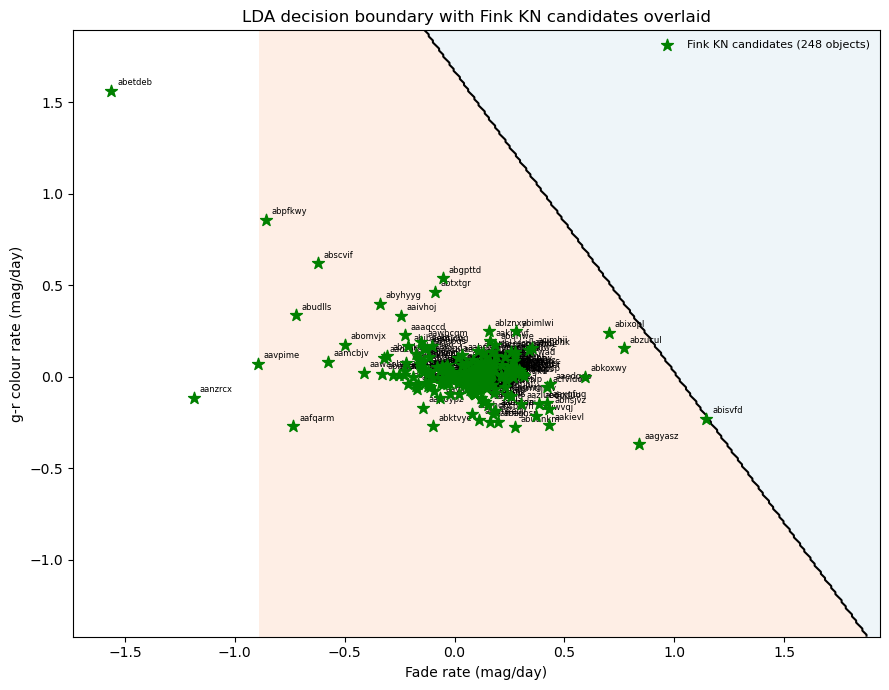

In [98]:
import matplotlib.pyplot as plt
import numpy as np
import joblib
lda = joblib.load(r'C:\Users\edcon\Downloads\lda_model.pkl')
X_train = joblib.load(r'C:\Users\edcon\Downloads\X_train.pkl')
print("loaded")

# Recompute decision boundary mesh
fr_min, fr_max = X_train[:, 0].min() - 0.2, X_train[:, 0].max() + 0.2
cr_min, cr_max = X_train[:, 1].min() - 0.2, X_train[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.linspace(fr_min, fr_max, 300),
                     np.linspace(cr_min, cr_max, 300))
Z = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fink_scoreable = results_df.dropna(subset=['fade_rate', 'colour_rate'])

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(xx, yy, Z, alpha=0.15, cmap="RdYlBu", levels=[-0.5, 0.5, 1.5])
ax.contour(xx, yy, Z, colors="black", linewidths=1.5, levels=[0.5])

ax.scatter(fink_scoreable["fade_rate"], fink_scoreable["colour_rate"],
           s=80, marker="*", color="green", zorder=5,
           label=f"Fink KN candidates ({len(fink_scoreable)} objects)")

for _, row in fink_scoreable.iterrows():
    ax.annotate(row['objectId'][-7:],
                (row['fade_rate'], row['colour_rate']),
                fontsize=6, xytext=(4, 4), textcoords='offset points')

ax.set_xlabel("Fade rate (mag/day)")
ax.set_ylabel("g-r colour rate (mag/day)")
ax.set_title("LDA decision boundary with Fink KN candidates overlaid")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

C:\Users\edcon\AppData\Local\Temp\ipykernel_19744\624962737.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=8)


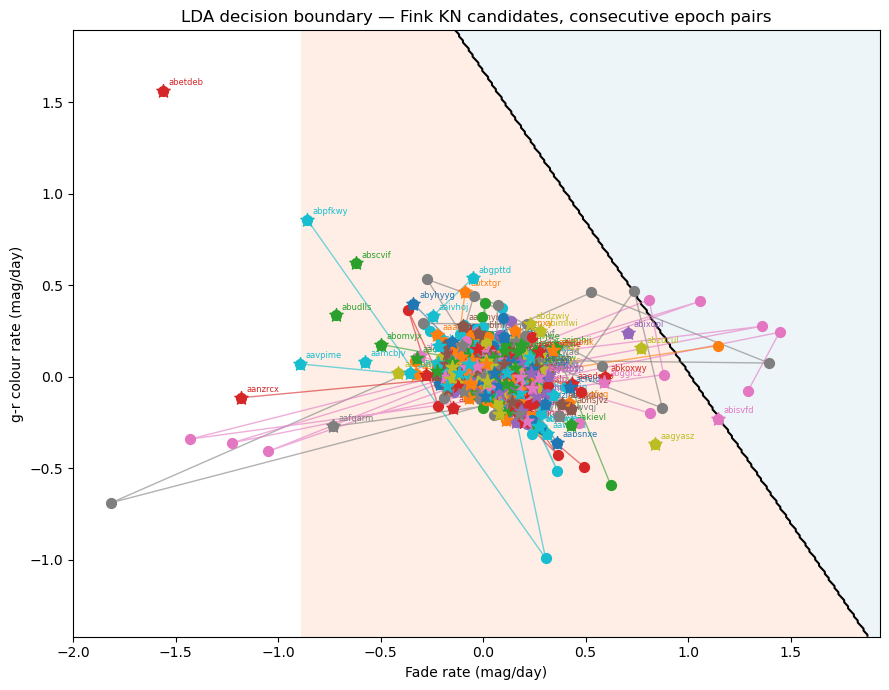

In [99]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(xx, yy, Z, alpha=0.15, cmap="RdYlBu", levels=[-0.5, 0.5, 1.5])
ax.contour(xx, yy, Z, colors="black", linewidths=1.5, levels=[0.5])

colors = plt.cm.tab10.colors

for i, (obj_id, lc) in enumerate(lightcurves.items()):
    lc = lc.copy()
    lc['band'] = lc['i:fid'].map({1: 'g', 2: 'r'})
    lc['night'] = lc['i:jd'].apply(np.floor)
    
    g_nightly = lc[lc['band']=='g'].groupby('night')['i:magpsf'].mean().reset_index()
    r_nightly = lc[lc['band']=='r'].groupby('night')['i:magpsf'].mean().reset_index()
    
    # Compute features for each consecutive r night pair
    points = []
    for j in range(len(r_nightly) - 1):
        dt = r_nightly['night'].iloc[j+1] - r_nightly['night'].iloc[j]
        dm = r_nightly['i:magpsf'].iloc[j+1] - r_nightly['i:magpsf'].iloc[j]
        if 0 < dt <= 2.0:
            fade_rate = dm / dt
            
            # find g-r colour at each of the two nights
            pairs = []
            for night in [r_nightly['night'].iloc[j], r_nightly['night'].iloc[j+1]]:
                diff = (g_nightly['night'] - night).abs()
                if diff.min() <= 1.0:
                    g_mag = g_nightly.iloc[diff.argsort().iloc[0]]['i:magpsf']
                    r_mag = r_nightly[r_nightly['night'] == night]['i:magpsf'].values[0]
                    pairs.append(g_mag - r_mag)
            
            if len(pairs) == 2:
                dt_c = r_nightly['night'].iloc[j+1] - r_nightly['night'].iloc[j]
                colour_rate = (pairs[1] - pairs[0]) / dt_c
                points.append((fade_rate, colour_rate))
    
    if len(points) == 0:
        continue
    
    color = colors[i % len(colors)]
    frs = [p[0] for p in points]
    crs = [p[1] for p in points]
    
    ax.plot(frs, crs, '-', color=color, alpha=0.6, linewidth=1)
    ax.scatter(frs, crs, s=50, color=color, zorder=5)
    ax.scatter(frs[0], crs[0], s=100, marker='*', color=color, zorder=6)
    ax.annotate(obj_id[-7:], (frs[0], crs[0]), fontsize=6,
                xytext=(4, 4), textcoords='offset points', color=color)

ax.set_xlabel("Fade rate (mag/day)")
ax.set_ylabel("g-r colour rate (mag/day)")
ax.set_title("LDA decision boundary — Fink KN candidates, consecutive epoch pairs")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


In [100]:
for obj_id, lc in lightcurves.items():
    lc = lc.copy()
    lc['band'] = lc['i:fid'].map({1: 'g', 2: 'r'})
    lc['night'] = lc['i:jd'].apply(np.floor)
    
    g_nightly = lc[lc['band']=='g'].groupby('night')['i:magpsf'].mean().reset_index()
    r_nightly = lc[lc['band']=='r'].groupby('night')['i:magpsf'].mean().reset_index()
    
    for j in range(len(r_nightly) - 1):
        dt = r_nightly['night'].iloc[j+1] - r_nightly['night'].iloc[j]
        dm = r_nightly['i:magpsf'].iloc[j+1] - r_nightly['i:magpsf'].iloc[j]
        if 0 < dt <= 2.0:
            fade_rate = dm / dt
            pairs = []
            for night in [r_nightly['night'].iloc[j], r_nightly['night'].iloc[j+1]]:
                diff = (g_nightly['night'] - night).abs()
                if diff.min() <= 1.0:
                    g_mag = g_nightly.iloc[diff.argsort().iloc[0]]['i:magpsf']
                    r_mag = r_nightly[r_nightly['night'] == night]['i:magpsf'].values[0]
                    pairs.append(g_mag - r_mag)
            if len(pairs) == 2:
                colour_rate = (pairs[1] - pairs[0]) / dt
                pred = lda.predict([[fade_rate, colour_rate]])[0]
                if pred == 1:
                    print(f"{obj_id} epoch {j}: fade={fade_rate:.3f} colour={colour_rate:.3f}")

ZTF26aafqarm epoch 9: fade=1.395 colour=0.075
ZTF25aawlutq epoch 8: fade=1.360 colour=0.277
ZTF25aawlutq epoch 14: fade=0.810 colour=0.422
ZTF25aawlutq epoch 16: fade=1.058 colour=0.413
ZTF25aawlutq epoch 18: fade=1.446 colour=0.244
ZTF25aawlutq epoch 21: fade=1.290 colour=-0.079
ZTF25aahtwad epoch 4: fade=0.737 colour=0.468
ZTF23aajaaqm epoch 7: fade=1.144 colour=0.169


## Real-Data Validation Using Fink ZTF Kilonova Candidates

To test the classifier on real photometric data, we queried the Fink broker API for recent 
kilonova candidates from the ZTF alert stream. Fink is one of seven official Rubin community 
brokers and has operated a dedicated kilonova classification module on ZTF data since 2021 
(Biswas et al. 2023). It uses a random forest classifier trained on principal components of 
simulated light curves to flag fast-fading transients as kilonova candidates.

We retrieved the 20 most recent Fink kilonova candidates and fetched the full g and r band 
light curves for each object via the Fink REST API. This returned 13 unique candidates with 
between 2 and 54 individual alerts each.

For each candidate, we computed the two classifier features: the r-band fade rate and the 
g-r colour rate. Detections on the same night were binned by taking the nightly mean magnitude. 
Features were only computed where consecutive nightly epochs were separated by two days or less, 
to avoid unphysical rates from sparse sampling.

The soft score classifier rejected all 13 scoreable candidates, with scores ranging from 
-0.58 to -2.66, well below the deployment threshold of 1.43. When plotted on the LDA decision 
boundary, all candidates fell clearly within the non-kilonova region of feature space.

This result is consistent with expectations. Fink's module is designed to flag fast transients 
broadly, resulting in a high contamination rate. The Stevenson et al. (2025) analysis estimated 
at least 30 contaminant events per month even under strict selection criteria. Our physically 
motivated features — fade rate and g-r colour rate — provide a more selective filter, rejecting 
objects that evolve too slowly or do not show the rapid reddening characteristic of kilonova ejecta.

This exercise demonstrates that the classifier pipeline runs correctly on real ZTF-format 
photometry and produces physically interpretable results. It is not a formal validation, as none 
of the Fink candidates have spectroscopic confirmation. However, the consistent rejection of 
all candidates is the expected outcome given the known contamination rate in untriggered surveys.
    

In [101]:
crossed = set()
for obj_id, lc in lightcurves.items():
    lc = lc.copy()
    lc['band'] = lc['i:fid'].map({1: 'g', 2: 'r'})
    lc['night'] = lc['i:jd'].apply(np.floor)
    g_nightly = lc[lc['band']=='g'].groupby('night')['i:magpsf'].mean().reset_index()
    r_nightly = lc[lc['band']=='r'].groupby('night')['i:magpsf'].mean().reset_index()
    for j in range(len(r_nightly) - 1):
        dt = r_nightly['night'].iloc[j+1] - r_nightly['night'].iloc[j]
        dm = r_nightly['i:magpsf'].iloc[j+1] - r_nightly['i:magpsf'].iloc[j]
        if 0 < dt <= 2.0:
            fade_rate = dm / dt
            pairs = []
            for night in [r_nightly['night'].iloc[j], r_nightly['night'].iloc[j+1]]:
                diff = (g_nightly['night'] - night).abs()
                if diff.min() <= 1.0:
                    g_mag = g_nightly.iloc[diff.argsort().iloc[0]]['i:magpsf']
                    r_mag = r_nightly[r_nightly['night'] == night]['i:magpsf'].values[0]
                    pairs.append(g_mag - r_mag)
            if len(pairs) == 2:
                colour_rate = (pairs[1] - pairs[0]) / dt
                pred = lda.predict([[fade_rate, colour_rate]])[0]
                if pred == 1:
                    crossed.add(obj_id)

print(f"Total candidates: {len(lightcurves)}")
print(f"Objects crossing LDA boundary: {len(crossed)}")
print(f"False positive rate: {len(crossed)/len(lightcurves)*100:.1f}%")
print(f"Objects: {crossed}")

Total candidates: 631
Objects crossing LDA boundary: 4
False positive rate: 0.6%
Objects: {'ZTF25aahtwad', 'ZTF23aajaaqm', 'ZTF25aawlutq', 'ZTF26aafqarm'}
